In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club' dataset.
Path to dataset files: /kaggle/input/lending-club


In [3]:
import os

for f in os.listdir(path):
    size_mb = os.path.getsize(os.path.join(path, f)) / 1e6
    print(f"{f}  —  {size_mb:,.0f} MB")

rejected_2007_to_2018Q4.csv.gz  —  255 MB
accepted_2007_to_2018Q4.csv.gz  —  393 MB
accepted_2007_to_2018q4.csv  —  0 MB
rejected_2007_to_2018q4.csv  —  0 MB


In [4]:
import numpy as np
import pandas as pd


In [5]:
file = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")
df=pd.read_csv(file,low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(2260701, 151)

In [7]:
sample = df.sample(n=50000, random_state=42)
sample.shape

(50000, 151)

In [8]:
pd.set_option("display.max_rows", 200)

overview = pd.DataFrame({
    "dtype": sample.dtypes.astype(str),
    "n_unique": sample.nunique(),
    "pct_missing": (sample.isna().mean() * 100).round(1),
    "example": sample.iloc[0],
})
overview

,dtype,n_unique,pct_missing,example
id,object,50000,0.0,39651438
member_id,float64,0,100.0,NaN
loan_amnt,float64,1318,0.0,32000.0
funded_amnt,float64,1318,0.0,32000.0
funded_amnt_inv,float64,1572,0.0,32000.0
term,object,2,0.0,60 months
int_rate,float64,520,0.0,10.49
installment,float64,18859,0.0,687.65
grade,object,7,0.0,B
sub_grade,object,35,0.0,B3


### Overview Analysis

In [9]:
print('--- Columns with n_unique = 1 ---')
overview[overview['n_unique'] == 1]


--- Columns with n_unique = 1 ---


,dtype,n_unique,pct_missing,example
policy_code,float64,1,0.0,1.0
hardship_type,object,1,99.5,NaN
deferral_term,float64,1,99.5,NaN
hardship_length,float64,1,99.5,NaN


In [10]:
print('\n--- Columns with n_unique close to 50000 (sample size) ---')
# Assuming sample size is 50000, consider a small tolerance
# For exact match, use overview[overview['n_unique'] == 50000]
# For 'close to', one might use a range, e.g., >= 49990
overview[overview['n_unique'] >= 49990]



--- Columns with n_unique close to 50000 (sample size) ---


,dtype,n_unique,pct_missing,example
id,object,50000,0.0,39651438
url,object,49998,0.0,https://lendingclub.com/browse/loanDetail.acti...


In [11]:
print('\n--- Columns with more than 90% missing ---')
overview[overview['pct_missing'] > 90.0]



--- Columns with more than 90% missing ---


,dtype,n_unique,pct_missing,example
member_id,float64,0,100.0,NaN
desc,object,2768,94.5,NaN
annual_inc_joint,float64,812,94.8,NaN
dti_joint,float64,1722,94.8,NaN
verification_status_joint,object,3,95.0,NaN
revol_bal_joint,float64,2287,95.3,NaN
sec_app_fico_range_low,float64,58,95.3,NaN
sec_app_fico_range_high,float64,58,95.3,NaN
sec_app_earliest_cr_line,object,411,95.3,NaN
sec_app_inq_last_6mths,float64,7,95.3,NaN


In [12]:
print('\n--- Columns whose meaning cannot work out from name and example value (subjective) ---')
# These are examples from the previous analysis, based on example values from overview
overview.loc[['sub_grade', 'url', 'policy_code']]



--- Columns whose meaning cannot work out from name and example value (subjective) ---


,dtype,n_unique,pct_missing,example
sub_grade,object,35,0.0,B3
url,object,49998,0.0,https://lendingclub.com/browse/loanDetail.acti...
policy_code,float64,1,0.0,1.0


In [13]:
print('\n--- Borrower vs. Loan Identifiers ---')
print("From the 'overview' DataFrame:")
print(f"'id' column: n_unique = {overview.loc['id']['n_unique']}, indicating it's a unique loan identifier.")
print(f"'member_id' column: n_unique = {overview.loc['member_id']['n_unique']}, pct_missing = {overview.loc['member_id']['pct_missing']}%, indicating it's entirely missing in this sample.")
print("Based on this sample, 'id' is a loan identifier, and 'member_id' is not usable as a borrower identifier due to missing values.")



--- Borrower vs. Loan Identifiers ---
From the 'overview' DataFrame:
'id' column: n_unique = 50000, indicating it's a unique loan identifier.
'member_id' column: n_unique = 0, pct_missing = 100.0%, indicating it's entirely missing in this sample.
Based on this sample, 'id' is a loan identifier, and 'member_id' is not usable as a borrower identifier due to missing values.


In [14]:
print(sample['loan_status'].value_counts(dropna=False))

loan_status
Fully Paid                                             23771
Current                                                19370
Charged Off                                             6015
Late (31-120 days)                                       505
In Grace Period                                          186
Late (16-30 days)                                        108
Does not meet the credit policy. Status:Fully Paid        24
Does not meet the credit policy. Status:Charged Off       19
NaN                                                        2
Name: count, dtype: int64


In [15]:
bad  = ['Charged Off', 'Default']
good = ['Fully Paid']

d = sample[sample['loan_status'].isin(bad + good)].copy()
d['target'] = d['loan_status'].isin(bad).astype(int)

print("rows kept:", len(d))
print("bad rate:", round(d['target'].mean(), 4))
print(d['target'].value_counts())
d['issue_d_dt'] = pd.to_datetime(d['issue_d'], format='%b-%Y')
print(d['issue_d_dt'].min(), "→", d['issue_d_dt'].max())


rows kept: 29786
bad rate: 0.2019
target
0    23771
1     6015
Name: count, dtype: int64
2007-08-01 00:00:00 → 2018-12-01 00:00:00


In [16]:
# DATA DICTIONARY REVIEW
# Purpose: understand what every column means from the official LendingClub
# dictionary, so feature decisions are based on definitions, not guesses.

import pandas as pd

# Load the official LendingClub data dictionary
dd = pd.read_csv(
    "https://raw.githubusercontent.com/d-osei/Lending-Club-Loan-Data/master/LCDataDictionary.csv"
)
dd.columns = ['name', 'description']
dd['name'] = dd['name'].str.strip()

# Join every column in our data to its official definition, so we can
# review meaning + missingness together in one scannable table.
review = pd.DataFrame({'name': sample.columns})
review = review.merge(dd, on='name', how='left')
review['pct_missing'] = review['name'].map(sample.isna().mean().round(3) * 100)
review['n_unique']    = review['name'].map(sample.nunique())

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 90)
review

,name,description,pct_missing,n_unique
0,id,A unique LC assigned ID for the loan listing.,0.0,50000
1,member_id,A unique LC assigned Id for the borrower member.,100.0,0
2,loan_amnt,"The listed amount of the loan applied for by the borrower. If at some point in time, t...",0.0,1318
3,funded_amnt,The total amount committed to that loan at that point in time.,0.0,1318
4,funded_amnt_inv,The total amount committed by investors for that loan at that point in time.,0.0,1572
5,term,The number of payments on the loan. Values are in months and can be either 36 or 60.,0.0,2
6,int_rate,Interest Rate on the loan,0.0,520
7,installment,The monthly payment owed by the borrower if the loan originates.,0.0,18859
8,grade,LC assigned loan grade,0.0,7
9,sub_grade,LC assigned loan subgrade,0.0,35


In [17]:
# FEATURE SCREENING (leakage + quality)
# Purpose: flag columns that cannot be used at application time (leakage)
# or are unusable (constant / near-empty), so feature selection is
# rule-based and auditable — not manual guesswork.


# Post-origination fields leak the outcome: they only exist AFTER a loan
# is issued and being repaid. Using them inflates performance and is
# impossible in production, where we score at the point of application.
leak_patterns = ['pymnt', 'rec_', 'recover', 'out_prncp', 'settle',
                 'hardship', 'last_', 'next_', 'coll', 'funded',
                 'total_pymnt', 'debt_settlement']

def screen(col):
    name = col.lower()
    if sample[col].nunique() <= 1:              return 'DROP: constant'
    if review.set_index('name').loc[col, 'pct_missing'] > 80:  return 'DROP: >80% missing'
    if any(p in name for p in leak_patterns):   return 'REVIEW: possible leakage'
    return 'keep candidate'

review['screen'] = review['name'].apply(screen)
review['screen'].value_counts()

,count
screen,
keep candidate,84
DROP: >80% missing,35
REVIEW: possible leakage,27
DROP: constant,5


In [42]:
def calc_woe_iv(data, feature, target='target'):
    g = data.groupby(feature,observed=True)[target].agg(['count', 'sum'])
    g.columns = ['total', 'bad']
    g['good'] = g['total'] - g['bad']

    # 0.5 adjustment: prevents division-by-zero / log(0) when a bin has
    # zero bads or zero goods (the "zero-cell problem"). Standard practice
    # in scorecard development.
    g['bad_adj']  = g['bad']  + 0.5
    g['good_adj'] = g['good'] + 0.5

    g['bad_pct']  = g['bad_adj']  / g['bad_adj'].sum()
    g['good_pct'] = g['good_adj'] / g['good_adj'].sum()

    g['woe'] = np.log(g['good_pct'] / g['bad_pct'])
    g['iv']  = (g['good_pct'] - g['bad_pct']) * g['woe']
    return g, g['iv'].sum()

# --- 1. Build a WOE lookup for every feature, and a function to apply it ---
def woe_map(data, feature, observed= True,target='target'):
    # Reuse our calc: returns the per-bin WOE table for this feature.
    g = data.groupby(feature)[target].agg(['count', 'sum'])
    g.columns = ['total', 'bad']; g['good'] = g['total'] - g['bad']
    g['bad_pct']  = (g['bad']  + 0.5) / (g['bad']  + 0.5).sum()
    g['good_pct'] = (g['good'] + 0.5) / (g['good'] + 0.5).sum()
    g['woe'] = np.log(g['good_pct'] / g['bad_pct'])
    return g['woe']                      # a lookup: bin -> woe value

In [43]:
woe_table, iv = calc_woe_iv(d, 'home_ownership')
print(woe_table[['total', 'good', 'bad', 'woe']])
print("\nIV:", round(iv, 4))

                total   good   bad       woe
home_ownership                              
ANY                 5      5     0  1.024058
MORTGAGE        14637  12016  2621  0.148696
NONE                4      1     3 -2.221135
OTHER               1      1     0 -0.275225
OWN              3199   2550   649 -0.005996
RENT            11940   9198  2742 -0.163667

IV: 0.023


In [44]:
from sklearn.model_selection import train_test_split

categorical = ['term', 'verification_status', 'home_ownership', 'purpose']
numeric = ['fico_range_low', 'acc_open_past_24mths', 'dti', 'avg_cur_bal',
           'loan_amnt', 'mths_since_recent_inq', 'tot_cur_bal',
           'inq_last_6mths', 'mort_acc', 'annual_inc', 'revol_util']

train, test = train_test_split(
    d, test_size=0.30, stratify=d['target'], random_state=42
)

print("train:", train.shape, "bad rate:", round(train['target'].mean(), 4))
print("test :", test.shape,  "bad rate:", round(test['target'].mean(), 4))

train: (20850, 153) bad rate: 0.2019
test : (8936, 153) bad rate: 0.202


In [45]:
import numpy as np

n_bins = {col: 10 for col in numeric}
n_bins['avg_cur_bal'] = 5
n_bins['mort_acc']    = 5
n_bins['revol_util'] = 5

bin_edges = {}
for col in numeric:
    _, edges = pd.qcut(train[col], q=n_bins[col], duplicates='drop', retbins=True)

    edges[0]  = -np.inf
    edges[-1] =  np.inf
    bin_edges[col] = edges

def apply_bins(frame):
    out = frame.copy()
    for col in numeric:
        out[col + '_bin'] = pd.cut(frame[col], bins=bin_edges[col])
    return out

train_b = apply_bins(train)
test_b  = apply_bins(test)

In [46]:
woe_maps = {}
for col in categorical:
    woe_maps[col] = woe_map(train_b, col)
for col in numeric:
    woe_maps[col] = woe_map(train_b, col + '_bin')

def to_woe(frame_binned):
    out = pd.DataFrame(index=frame_binned.index)
    for col in categorical:
        out[col] = frame_binned[col].map(woe_maps[col]).astype(float).fillna(0)
    for col in numeric:
        out[col] = frame_binned[col + '_bin'].map(woe_maps[col]).astype(float).fillna(0)
    return out

X_train = to_woe(train_b)
X_test  = to_woe(test_b)
y_train = train['target']
y_test  = test['target']

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("unseen bins mapped to 0 in test:", (X_test == 0).sum().sum())

X_train: (20850, 15)  X_test: (8936, 15)
unseen bins mapped to 0 in test: 2628


/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp

In [47]:
iv_results = []
for col in categorical:
    _, iv = calc_woe_iv(train_b, col)
    iv_results.append((col, iv))
for col in numeric:
    _, iv = calc_woe_iv(train_b, col + '_bin')
    iv_results.append((col, iv))

iv_table = pd.DataFrame(iv_results, columns=['feature', 'IV'])
iv_table = iv_table.sort_values('IV', ascending=False).reset_index(drop=True)
iv_table

,feature,IV
0,term,0.177539
1,fico_range_low,0.131518
2,dti,0.087014
3,acc_open_past_24mths,0.061088
4,verification_status,0.057524
5,loan_amnt,0.045555
6,avg_cur_bal,0.042358
7,tot_cur_bal,0.036358
8,revol_util,0.029889
9,annual_inc,0.026899


In [48]:
#VALIDATION: discrimination on the HELD-OUT test set
# The real test — data the model never saw during fitting.
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

model = sm.Logit(y_train, X_train_c).fit()
print(model.summary())

test_pd = model.predict(X_test_c)
auc  = roc_auc_score(y_test, test_pd)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_test, test_pd)
ks = max(tpr - fpr)

print(f"AUC : {auc:.4f}\nGini: {gini:.4f}\nKS  : {ks:.4f}")

Optimization terminated successfully.
         Current function value: 0.460887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                20850
Model:                          Logit   Df Residuals:                    20834
Method:                           MLE   Df Model:                           15
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                 0.08382
Time:                        16:57:31   Log-Likelihood:                -9609.5
converged:                       True   LL-Null:                       -10489.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.3783      0.018    -74.725      0.000      -1.414      -1.

In [49]:
# tot_cur_bal is insignificant (p=0.646) — remove and refit.

X_train2 = X_train.drop(columns='tot_cur_bal')
X_test2  = X_test.drop(columns='tot_cur_bal')

X_train2_c = sm.add_constant(X_train2)
X_test2_c  = sm.add_constant(X_test2)

model2 = sm.Logit(y_train, X_train2_c).fit()
model2.summary()

Optimization terminated successfully.
         Current function value: 0.460921
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:                20850
Model:                          Logit   Df Residuals:                    20835
Method:                           MLE   Df Model:                           14
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                 0.08375
Time:                        16:57:31   Log-Likelihood:                -9610.2
converged:                       True   LL-Null:                       -10489.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.3784      0.018    -74.730      0.000      -1.415      -1.342
term                     -0.9145      0.046    -19.839      0.000      -1.005      -0.824
verification_status      -0.3606      0.079     -4.540      0.000      -0.516      -0.205
home_ownership           -0.8156      0.145     -5.638      0.000      -1.099      -0.532
purpose                  -0.7456      0.142     -5.236      0.000      -1.025      -0.467
fico_range_low           -0.8291      0.061    -13.486      0.000      -0.950      -0.709
acc_open_past_24mths     -0.7824      0.080     -9.747      0.000      -0.940      -0.625
dti                      -0.5972      0.066     -9.109      0.000      -0.726      -0.469
avg_cur_bal              -0.3626      0.117     -3.099      0.002      -0.592      -0.133
loan_amnt                -0.8702      0.109     -8.011      0.000      -1.083      -0.657
mths_since_recent_inq    -0.5785      0.139     -4.168      0.000      -0.851      -0.306
inq_last_6mths           -0.5426      0.131     -4.144      0.000      -0.799      -0.286
mort_acc                 -0.4161      0.181     -2.295      0.022      -0.771      -0.061
annual_inc               -1.2759      0.137     -9.280      0.000      -1.545      -1.006
revol_util               -0.2327      0.128     -1.819      0.069      -0.483       0.018
=========================================================================================
"""

In [50]:
X_train2 = X_train.drop(columns='tot_cur_bal')
X_test2  = X_test.drop(columns='tot_cur_bal')

model2 = sm.Logit(y_train, sm.add_constant(X_train2)).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.460921
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                20850
Model:                          Logit   Df Residuals:                    20835
Method:                           MLE   Df Model:                           14
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                 0.08375
Time:                        16:57:32   Log-Likelihood:                -9610.2
converged:                       True   LL-Null:                       -10489.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.3784      0.018    -74.730      0.000      -1.415      -1.

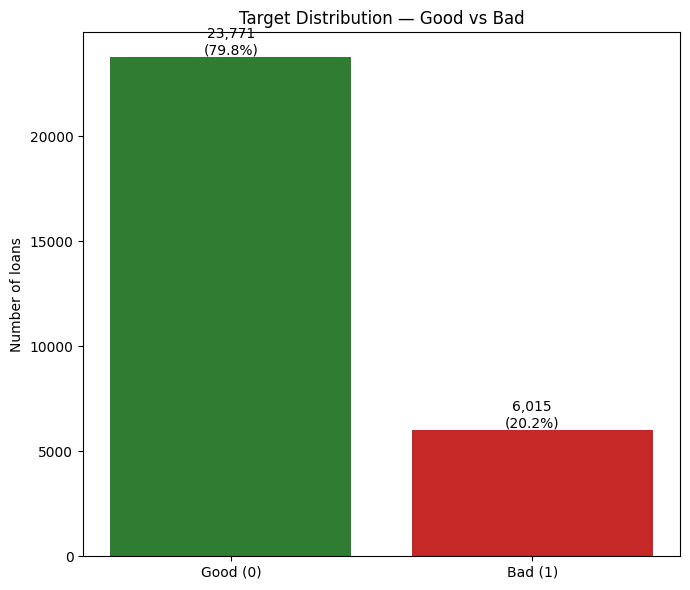

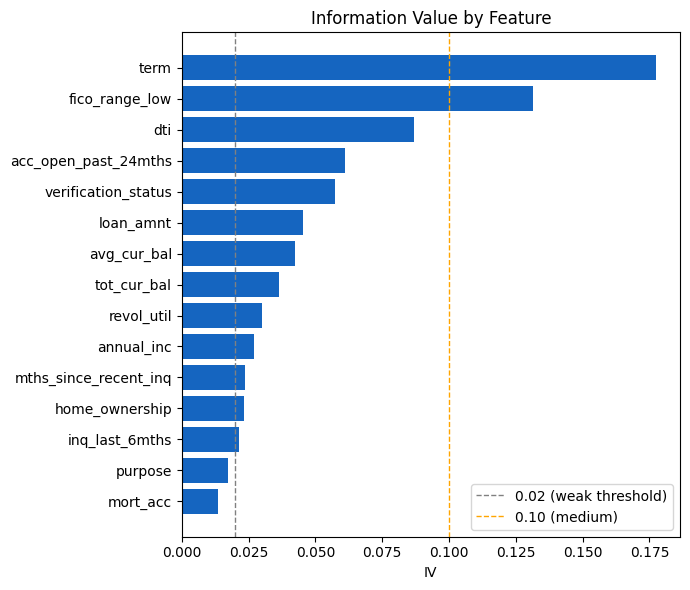

In [51]:
import matplotlib.pyplot as plt

# --- Plot 1: Target balance (the default rate, visually) ---
plt.figure(figsize=(7,6))
counts = d['target'].value_counts().sort_index()
plt.bar(['Good (0)', 'Bad (1)'], counts.values, color=['#2E7D32', '#C62828'])
plt.title('Target Distribution — Good vs Bad')
plt.ylabel('Number of loans')
for i, v in enumerate(counts.values):
    plt.text(i, v, f'{v:,}\n({v/counts.sum()*100:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# --- Plot 2: IV ranking (feature predictive power) ---
plt.figure(figsize=(7,6))
iv_sorted = iv_table.sort_values('IV')          # ascending so strongest is on top
plt.barh(iv_sorted['feature'], iv_sorted['IV'], color='#1565C0')
plt.axvline(0.02, color='grey', ls='--', lw=1, label='0.02 (weak threshold)')
plt.axvline(0.10, color='orange', ls='--', lw=1, label='0.10 (medium)')
plt.title('Information Value by Feature')
plt.xlabel('IV')
plt.legend()
plt.tight_layout()
plt.show()

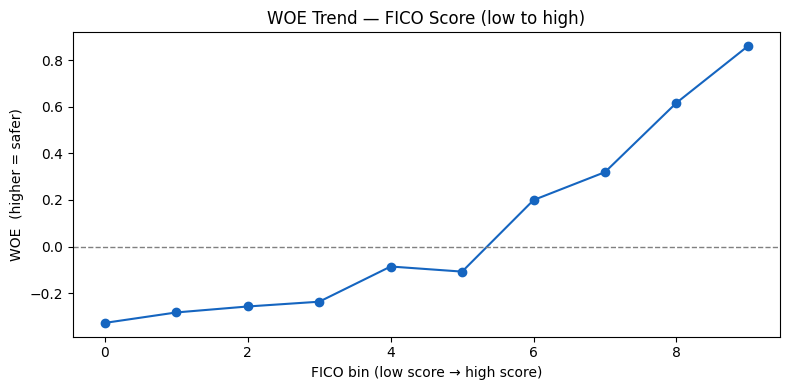

In [52]:
import matplotlib.pyplot as plt

# WOE trend for FICO score — should slope cleanly from risky to safe
woe_fico = woe_maps['fico_range_low'].sort_index()

plt.figure(figsize=(8,4))
plt.plot(range(len(woe_fico)), woe_fico.values, marker='o', color='#1565C0')
plt.axhline(0, color='grey', ls='--', lw=1)
plt.title('WOE Trend — FICO Score (low to high)')
plt.xlabel('FICO bin (low score → high score)')
plt.ylabel('WOE  (higher = safer)')
plt.tight_layout()
plt.show()

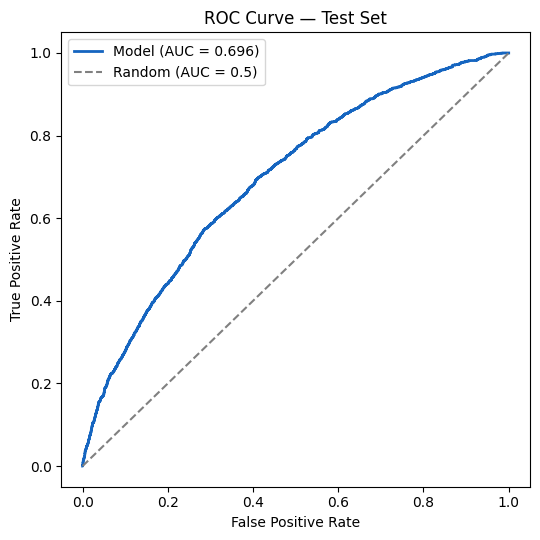

In [53]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_pd)

plt.figure(figsize=(5.5,5.5))
plt.plot(fpr, tpr, color='#1565C0', lw=2, label=f'Model (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='grey', ls='--', label='Random (AUC = 0.5)')
plt.title('ROC Curve — Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
test_pd2 = model2.predict(sm.add_constant(X_test2))

val = pd.DataFrame({'pd': test_pd2.values, 'target': y_test.values})
val = val.sort_values('pd', ascending=False).reset_index(drop=True)

val['cum_pop'] = (val.index + 1) / len(val)
val['cum_bad'] = val['target'].cumsum() / val['target'].sum()

for p in [0.10, 0.20, 0.30, 0.40, 0.50]:
    row = val[val['cum_pop'] >= p].iloc[0]
    print(f"riskiest {p:.0%} of applicants → captures {row['cum_bad']:.1%} of all defaults")

riskiest 10% of applicants → captures 22.4% of all defaults
riskiest 20% of applicants → captures 38.2% of all defaults
riskiest 30% of applicants → captures 50.7% of all defaults
riskiest 40% of applicants → captures 62.7% of all defaults
riskiest 50% of applicants → captures 72.3% of all defaults


In [55]:
val['band'] = pd.cut(val['cum_pop'], bins=[0, 0.25, 0.50, 0.75, 1.0],
                     labels=['B1 riskiest', 'B2', 'B3', 'B4 safest'])

bands = val.groupby('band', observed=True).agg(
    n=('target', 'size'), bads=('target', 'sum'), avg_pd=('pd', 'mean'))
bands['actual_bad_rate'] = bands['bads'] / bands['n']
bands['pct_of_all_bads'] = bands['bads'] / bands['bads'].sum()
bands

,n,bads,avg_pd,actual_bad_rate,pct_of_all_bads
band,,,,,
B1 riskiest,2234,802,0.374874,0.358997,0.444321
B2,2234,503,0.218765,0.225157,0.278670
B3,2234,327,0.145716,0.146374,0.181163
B4 safest,2234,173,0.079234,0.077440,0.095845


In [56]:
rows = []
for approve in np.arange(0.50, 1.01, 0.05):
    n_decline = int(len(val) * (1 - approve))
    approved = val.iloc[n_decline:]
    rows.append({
        'approval_rate': round(approve, 2),
        'bad_rate_of_approved': round(approved['target'].mean(), 4),
        'defaults_avoided': round(1 - approved['target'].sum() / val['target'].sum(), 4)
    })

pd.DataFrame(rows)

,approval_rate,bad_rate_of_approved,defaults_avoided
0,0.50,0.1119,0.7230
1,0.55,0.1194,0.6748
2,0.60,0.1257,0.6266
3,0.65,0.1313,0.5773
4,0.70,0.1423,0.5069
5,0.75,0.1496,0.4443
6,0.80,0.1562,0.3812
7,0.85,0.1659,0.3019
8,0.90,0.1741,0.2244
9,0.95,0.1857,0.1263


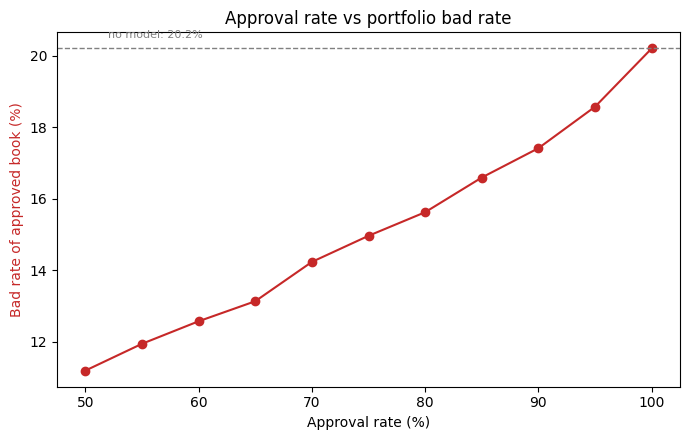

In [57]:
import matplotlib.pyplot as plt
t = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(7,4.5))
ax1.plot(t['approval_rate']*100, t['bad_rate_of_approved']*100,
         marker='o', color='#C62828')
ax1.set_xlabel('Approval rate (%)')
ax1.set_ylabel('Bad rate of approved book (%)', color='#C62828')
ax1.axhline(20.2, ls='--', lw=1, color='grey')
ax1.text(52, 20.5, 'no model: 20.2%', fontsize=8, color='grey')
ax1.set_title('Approval rate vs portfolio bad rate')
plt.tight_layout(); plt.show()

In [58]:
from sklearn.ensemble import HistGradientBoostingClassifier

feats_num = [c for c in numeric if c != 'tot_cur_bal']

def raw_matrix(frame):
    X = frame[feats_num].copy()
    dummies = pd.get_dummies(frame[categorical])
    return pd.concat([X, dummies], axis=1)

Xr_train = raw_matrix(train)
Xr_test  = raw_matrix(test).reindex(columns=Xr_train.columns, fill_value=0)

print(Xr_train.shape, Xr_test.shape)

(20850, 34) (8936, 34)


In [59]:
gbm = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=4,
    early_stopping=True, validation_fraction=0.15, random_state=42
)
gbm.fit(Xr_train, y_train)

gbm_pd = gbm.predict_proba(Xr_test)[:, 1]

auc_g  = roc_auc_score(y_test, gbm_pd)
gini_g = 2 * auc_g - 1
fpr_g, tpr_g, _ = roc_curve(y_test, gbm_pd)
ks_g = max(tpr_g - fpr_g)

print(f"GBM  → AUC {auc_g:.4f} | Gini {gini_g:.4f} | KS {ks_g:.4f}")
print(f"Logit→ AUC {roc_auc_score(y_test, test_pd2):.4f} | Gini 0.3918 | KS 0.2872")

GBM  → AUC 0.7006 | Gini 0.4012 | KS 0.2888
Logit→ AUC 0.6958 | Gini 0.3918 | KS 0.2872


In [60]:
g = pd.DataFrame({'pd': gbm_pd, 'target': y_test.values})
g = g.sort_values('pd', ascending=False).reset_index(drop=True)
g['cum_pop'] = (g.index + 1) / len(g)
g['band'] = pd.cut(g['cum_pop'], bins=[0,0.25,0.5,0.75,1.0],
                   labels=['B1','B2','B3','B4'])

g.groupby('band', observed=True).agg(
    avg_pd=('pd','mean'), actual=('target','mean'))

,avg_pd,actual
band,,
B1,0.363273,0.365264
B2,0.215552,0.221576
B3,0.147972,0.147717
B4,0.088611,0.073411


In [61]:
rng = np.random.default_rng(42)
diffs = []
for _ in range(500):
    i = rng.integers(0, len(y_test), len(y_test))
    yb = y_test.values[i]
    if yb.sum() == 0: continue
    diffs.append(roc_auc_score(yb, gbm_pd[i]) - roc_auc_score(yb, test_pd2.values[i]))

diffs = np.array(diffs)
print(f"mean AUC gap {diffs.mean():.4f}, 95% CI [{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]")

mean AUC gap 0.0049, 95% CI [-0.0006, 0.0105]


In [62]:
for col in feats_num:
    w = woe_maps[col].sort_index()
    diffs = np.diff(w.values)
    mono = (diffs >= 0).all() or (diffs <= 0).all()
    print(f"{col:25s} {'monotonic' if mono else '*** NOT monotonic'}")

fico_range_low            *** NOT monotonic
acc_open_past_24mths      *** NOT monotonic
dti                       *** NOT monotonic
avg_cur_bal               *** NOT monotonic
loan_amnt                 *** NOT monotonic
mths_since_recent_inq     *** NOT monotonic
inq_last_6mths            monotonic
mort_acc                  monotonic
annual_inc                *** NOT monotonic
revol_util                monotonic


In [63]:
from scipy.stats import spearmanr

for col in feats_num:
    v = woe_maps[col].sort_index().values
    steps = np.diff(v)
    reversals = min((steps > 0).sum(), (steps < 0).sum())
    rho = spearmanr(np.arange(len(v)), v).statistic
    print(f"{col:22s} reversals={reversals}  spearman={rho:+.2f}")

fico_range_low         reversals=1  spearman=+0.99
acc_open_past_24mths   reversals=2  spearman=-0.93
dti                    reversals=1  spearman=-0.99
avg_cur_bal            reversals=1  spearman=+0.90
loan_amnt              reversals=2  spearman=-0.95
mths_since_recent_inq  reversals=1  spearman=+0.95
inq_last_6mths         reversals=0  spearman=-1.00
mort_acc               reversals=0  spearman=+1.00
annual_inc             reversals=1  spearman=+0.96
revol_util             reversals=0  spearman=-1.00


In [64]:
cut = pd.Timestamp('2016-01-01')
tr_oot = d[d['issue_d_dt'] <  cut].copy()
te_oot = d[d['issue_d_dt'] >= cut].copy()

print("train pre-2016:", len(tr_oot), "bad rate:", round(tr_oot['target'].mean(), 4))
print("test  2016+   :", len(te_oot), "bad rate:", round(te_oot['target'].mean(), 4))

train pre-2016: 18231 bad rate: 0.1866
test  2016+   : 11555 bad rate: 0.2262


In [65]:
def fit_oot(tr, te):
    edges = {}
    for c in feats_num:
        _, e = pd.qcut(tr[c], q=n_bins[c], duplicates='drop', retbins=True)
        e[0], e[-1] = -np.inf, np.inf
        edges[c] = e

    def binned(f):
        o = f.copy()
        for c in feats_num:
            o[c + '_bin'] = pd.cut(f[c], bins=edges[c])
        return o

    trb, teb = binned(tr), binned(te)

    maps = {}
    for c in categorical:
        maps[c] = woe_map(trb, c)
    for c in feats_num:
        maps[c] = woe_map(trb, c + '_bin')

    def tow(fb):
        o = pd.DataFrame(index=fb.index)
        for c in categorical:
            o[c] = fb[c].map(maps[c]).astype(float).fillna(0)
        for c in feats_num:
            o[c] = fb[c + '_bin'].map(maps[c]).astype(float).fillna(0)
        return o

    Xtr, Xte = tow(trb), tow(teb)
    m = sm.Logit(tr['target'], sm.add_constant(Xtr)).fit(disp=0)
    p = m.predict(sm.add_constant(Xte))

    a = roc_auc_score(te['target'], p)
    f_, t_, _ = roc_curve(te['target'], p)
    return m, p, a, 2*a - 1, max(t_ - f_)


m_oot, p_oot, auc_o, gini_o, ks_o = fit_oot(tr_oot, te_oot)

print(f"OOT          → AUC {auc_o:.4f} | Gini {gini_o:.4f} | KS {ks_o:.4f}")
print(f"Random split → AUC 0.6958 | Gini 0.3915 | KS 0.2880")
print(f"\npredicted mean PD: {p_oot.mean():.4f}   actual bad rate: {te_oot['target'].mean():.4f}")

OOT          → AUC 0.6851 | Gini 0.3703 | KS 0.2765
Random split → AUC 0.6958 | Gini 0.3915 | KS 0.2880

predicted mean PD: 0.1781   actual bad rate: 0.2262


/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp/ipykernel_3468/1312228637.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby(feature)[target].agg(['count', 'sum'])
/tmp

In [66]:
p_old = tr_oot['target'].mean()
p_new = te_oot['target'].mean()

shift = np.log((p_new / (1 - p_new)) / (p_old / (1 - p_old)))

logit_old = np.log(p_oot / (1 - p_oot))
p_recal   = 1 / (1 + np.exp(-(logit_old + shift)))

print(f"intercept shift: {shift:+.4f}\n")
print(f"before → mean PD {p_oot.mean():.4f}  vs actual {p_new:.4f}")
print(f"after  → mean PD {p_recal.mean():.4f}  vs actual {p_new:.4f}\n")
print(f"Gini before: {2*roc_auc_score(te_oot['target'], p_oot)-1:.4f}")
print(f"Gini after : {2*roc_auc_score(te_oot['target'], p_recal)-1:.4f}")

intercept shift: +0.2428

before → mean PD 0.1781  vs actual 0.2262
after  → mean PD 0.2128  vs actual 0.2262

Gini before: 0.3703
Gini after : 0.3703


In [68]:
PDO        = 20    # points to double the odds
base_score = 600   # score at the reference point
base_odds = (1 - p_new) / p_new     # your actual odds, about 3.4
offset = base_score - factor * np.log(base_odds)

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

good_bad_odds = (1 - p_recal) / p_recal
scores = offset + factor * np.log(good_bad_odds)

print(f"factor {factor:.2f}   offset {offset:.2f}")
print(f"score range: {scores.min():.0f} to {scores.max():.0f}, median {np.median(scores):.0f}\n")

chk = pd.DataFrame({'score': scores, 'target': te_oot['target'].values})
chk['band'] = pd.qcut(chk['score'], 10, labels=False)
print(chk.groupby('band').agg(min_score=('score','min'),
                              max_score=('score','max'),
                              bad_rate=('target','mean')).round(3))

factor 28.85   offset 564.52
score range: 535 to 681, median 607

      min_score  max_score  bad_rate
band                                
0       534.802    577.434     0.445
1       577.452    588.403     0.352
2       588.433    595.830     0.311
3       595.834    601.494     0.269
4       601.500    607.124     0.228
5       607.125    612.500     0.197
6       612.501    618.475     0.164
7       618.481    625.907     0.124
8       625.911    636.477     0.104
9       636.501    681.084     0.069


In [69]:
chars  = categorical + feats_num
n      = len(chars)
alpha  = model2.params['const']

rows = []
for c in chars:
    beta = model2.params[c]
    for attribute, woe in woe_maps[c].items():
        pts = -(beta * woe + alpha / n) * factor + offset / n
        rows.append({'characteristic': c,
                     'attribute': str(attribute),
                     'woe': round(woe, 3),
                     'points': round(pts)})

scorecard = pd.DataFrame(rows)
scorecard[scorecard['characteristic'] == 'fico_range_low']

,characteristic,attribute,woe,points
24,fico_range_low,"(-inf, 665.0]",-0.328,35
25,fico_range_low,"(665.0, 670.0]",-0.283,36
26,fico_range_low,"(670.0, 675.0]",-0.257,37
27,fico_range_low,"(675.0, 680.0]",-0.237,38
28,fico_range_low,"(680.0, 690.0]",-0.086,41
29,fico_range_low,"(690.0, 695.0]",-0.108,41
30,fico_range_low,"(695.0, 705.0]",0.199,48
31,fico_range_low,"(705.0, 720.0]",0.319,51
32,fico_range_low,"(720.0, 740.0]",0.617,58
33,fico_range_low,"(740.0, inf]",0.860,64


In [70]:
manual = -(X_test2 * model2.params[X_test2.columns]).sum(axis=1) * factor \
         - alpha * factor + offset
direct = offset + factor * np.log((1 - test_pd2) / test_pd2)
print("max difference:", abs(manual - direct).max())

max difference: 1.1368683772161603e-13


Limitations

Reject inference. The model trains only on accepted applicants, so it learns from a population already filtered by LendingClub's credit policy. Applied to all applicants it would encounter risk profiles it never observed. Standard remedies are parcelling or fuzzy augmentation, neither implemented here.

Maturity bias. Only resolved loans are included, excluding roughly 40% of the sample that remained current. This favours older vintages and 36-month terms. A fixed performance window would be the correct alternative.

Right-censoring. Bad rates rise from 18.7% pre-2016 to 22.6% afterwards. Later originations enter the resolved sample only by finishing early, and defaults resolve faster than full repayments, so the gap is likely an artefact rather than genuine deterioration.

Missing values. Unmapped bins receive neutral WoE of zero. This discards any predictive signal carried by missingness itself.

Model selection on the test set. The same holdout informed both feature decisions and the champion choice. A three-way split would be cleaner.
